# Klasifikasi Kupu-Kupu Beracun Menggunakan Gabungan Fitur GLCM & Fitur Warna HSV dengan KNN
---
## Pengolahan Citra Digital

Notebook ini berisi implementasi klasifikasi kupu-kupu beracun (Toxic) dan tidak beracun (Non-Toxic) menggunakan algoritma **K-Nearest Neighbors (KNN)** dengan menggabungkan dua jenis fitur utama:
1. **Fitur Tekstur (GLCM = contrast, homogenity, energy, correlation, entropy)**: Untuk menganalisis pola permukaan sayap menggunakan statistik orde kedua.
2. **Fitur Warna (HSV)**: Untuk menangkap informasi warna peringatan (*aposematism*) seperti merah, orange, dan kuning terang pada kupu-kupu beracun.

### Alur Kerja (Workflow):
1. **Definisi Ground Truth**: Mengelompokkan spesies kupu-kupu menjadi kelas **Beracun (1)** dan **Tidak Beracun (0)** berdasarkan literatur biologi.
2. **Pemuatan Dataset**: Membaca gambar dari folder `Kelompok9_PCD/` untuk partisi *train*, *valid*, dan *test*.
3. **Ekstraksi Fitur Gabungan**:
   - **Tekstur GLCM (Grayscale)**: Menghasilkan 24 fitur (6 properti $\times$ 4 sudut arah $\times$ 1 jarak piksel).
   - **Warna HSV (Color)**: Menghasilkan 6 fitur (Rata-rata dan Standar Deviasi dari kanal Hue, Saturation, dan Value).
   - Total fitur per citra = $24 + 6 = 30$ fitur.
4. **Normalisasi Fitur**: Menggunakan `StandardScaler` agar setiap fitur memiliki rentang nilai yang setara sebelum masuk ke KNN.
5. **Hyperparameter Tuning KNN**: Mencari nilai $K$ terbaik berdasarkan performa pada data Validation.
6. **Evaluasi Akhir**: Menguji model KNN dengan $K$ terbaik pada data Test dan menampilkan Confusion Matrix, Classification Report, Kurva ROC-AUC, serta visualisasi sampel hasil prediksi.

In [1]:
import os
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, f1_score

# Menonaktifkan peringatan
warnings.filterwarnings('ignore')

# Set seed untuk reproduksibilitas
np.random.seed(42)
random.seed(42)

print("Seluruh library berhasil dimuat!")

Seluruh library berhasil dimuat!


In [2]:
# Definisi Spesies Beracun (Ground Truth) berdasarkan referensi biologi
TOXIC_SPECIES = {
    'MONARCH',             # toksin glikosida jantung dari tanaman milkweed
    'ATALA',               # toksin cycasin dari cycad
    'PIPEVINE SWALLOW',    # asam aristolochic dari pipevine
    'BLUE SPOTTED CROW',   # toksin dari tanaman inang
    'GREAT EGGFLY',        # mimetik spesies beracun
    'DANAID EGGFLY',       # mimetik Monarch
    'VICEROY',             # mimikri Batesian terhadap Monarch
    'JULIA',               # Heliconius grup — toksik ringan
    'MALACHITE',           # zat kimia defensif berbau pekat
    'RED CRACKER',         # pola warna peringatan (aposematism)
    'CAIRNS BIRDWING',     # toksin ringan
    'ZEBRA LONG WING',     # toksin dari mengonsumsi serbuk sari
    'RED POSTMAN',         # cyanogenic glycoside
    'STRAITED QUEEN',      # kerabat Monarch dengan toksin serupa
    'SIXSPOT BURNET MOTH', # sangat beracun — mengandung sianida
    'CINNABAR MOTH',       # alkaloid pyrrolizidine
    'GARDEN TIGER MOTH',   # pertahanan toksin tanaman inang
    'ROSY MAPLE MOTH',     # warna peringatan kuat kuning-merah jambu
    'IO MOTH',             # duri (spine) beracun saat larva
    'BANDED TIGER MOTH',   # alkaloid defensif pahit
}

print(f"Total spesies beracun yang didefinisikan: {len(TOXIC_SPECIES)}")
print("Daftar spesies beracun:")
for idx, sp in enumerate(sorted(TOXIC_SPECIES), 1):
    print(f"{idx}. {sp}")

Total spesies beracun yang didefinisikan: 20
Daftar spesies beracun:
1. ATALA
2. BANDED TIGER MOTH
3. BLUE SPOTTED CROW
4. CAIRNS BIRDWING
5. CINNABAR MOTH
6. DANAID EGGFLY
7. GARDEN TIGER MOTH
8. GREAT EGGFLY
9. IO MOTH
10. JULIA
11. MALACHITE
12. MONARCH
13. PIPEVINE SWALLOW
14. RED CRACKER
15. RED POSTMAN
16. ROSY MAPLE MOTH
17. SIXSPOT BURNET MOTH
18. STRAITED QUEEN
19. VICEROY
20. ZEBRA LONG WING


## Sel 4 — Pemuatan Dataset dan Ekstraksi Fitur Gabungan (GLCM + Warna HSV)

Fungsi di bawah ini mengekstrak fitur gabungan dari gambar:
1. **Grayscale (GLCM)**: 6 properti tekstur (*Contrast, Correlation, Energy, Homogeneity, Entropy, ASM, Dissimilarity*) $\times$ 4 sudut arah ($0, \pi/4, \pi/2, 3\pi/4$) = 24 fitur.
2. **Color (HSV)**: Nilai Rerata (mean) dan Standar Deviasi (std) untuk kanal Hue, Saturation, dan Value = 6 fitur.

Total kombinasi fitur per gambar = 30 fitur.

**Optimasi Caching:** Untuk mencegah proses ekstraksi ulang yang memakan waktu (total ~13.600+ gambar), ekstraksi fitur gabungan akan disimpan ke file CSV di folder `output_csv/`. Jika file CSV sudah ada, notebook akan langsung memuat fitur dari CSV tersebut.

In [3]:
BASE_DIR = Path('./Kelompok9_PCD')
TRAIN_DIR = BASE_DIR / 'train'
VALID_DIR = BASE_DIR / 'valid'
TEST_DIR = BASE_DIR / 'test'

CACHE_DIR = Path('output_csv')
CACHE_DIR.mkdir(exist_ok=True)

def extract_combined_features(filepath):
    # 1. Ekstraksi Fitur Tekstur GLCM (Grayscale)
    img_gray = cv2.imread(str(filepath), cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return None
    img_gray_res = cv2.resize(img_gray, (128, 128))
    
    glcm = graycomatrix(img_gray_res, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], 
                        levels=256, symmetric=True, normed=True)
    properties = ['contrast', 'correlation', 'energy', 'homogeneity', 'ASM', 'dissimilarity']
    glcm_features = []
    for prop in properties:
        glcm_features.extend(graycoprops(glcm, prop).flatten())
        
    # 2. Ekstraksi Fitur Warna HSV
    img_bgr = cv2.imread(str(filepath))
    if img_bgr is None:
        return None
    img_bgr_res = cv2.resize(img_bgr, (128, 128))
    img_hsv = cv2.cvtColor(img_bgr_res, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)
    color_features = [
        h.mean(), h.std(),
        s.mean(), s.std(),
        v.mean(), v.std()
    ]
    
    # Gabungkan fitur tekstur (24) dan warna (6)
    return glcm_features + color_features

def load_and_extract_split(split_dir, cache_csv):
    if os.path.exists(cache_csv):
        print(f"[{split_dir.name.upper()}] Memuat fitur Gabungan dari cache CSV: {cache_csv}")
        df_cache = pd.read_csv(cache_csv)
        y = df_cache['label'].values
        filepaths = df_cache['filepath'].tolist()
        species = df_cache['species'].tolist()
        
        # Ambil kolom fitur saja (feat_0 sampai feat_29)
        feat_cols = [c for c in df_cache.columns if c.startswith('feat_')]
        X = df_cache[feat_cols].values
        return X, y, filepaths, species
        
    features_list = []
    labels_list = []
    filepaths_list = []
    species_list = []
    
    # Ambil subfolder spesies
    subdirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    
    print(f"[{split_dir.name.upper()}] Memproses dan mengekstrak fitur Gabungan dari folder...")
    for sp_dir in tqdm(subdirs):
        species_name = sp_dir.name.upper()
        # Label 1 jika beracun (Toxic), 0 jika aman (Non-toxic)
        label = 1 if species_name in TOXIC_SPECIES else 0
        
        for img_path in sp_dir.glob('*.*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                feats = extract_combined_features(img_path)
                if feats is not None:
                    features_list.append(feats)
                    labels_list.append(label)
                    filepaths_list.append(str(img_path))
                    species_list.append(sp_dir.name)
                    
    X = np.array(features_list)
    y = np.array(labels_list)
    
    # Simpan ke cache CSV
    df_to_cache = pd.DataFrame(X, columns=[f'feat_{i}' for i in range(X.shape[1])])
    df_to_cache['label'] = y
    df_to_cache['filepath'] = filepaths_list
    df_to_cache['species'] = species_list
    df_to_cache.to_csv(cache_csv, index=False)
    print(f"[{split_dir.name.upper()}] Ekstraksi selesai dan disimpan ke cache CSV: {cache_csv}")
    
    return X, y, filepaths_list, species_list

# Ekstraksi fitur untuk Train, Valid, dan Test splits
X_train, y_train, train_paths, train_species = load_and_extract_split(TRAIN_DIR, CACHE_DIR / 'glcm_color_train.csv')
X_val, y_val, val_paths, val_species = load_and_extract_split(VALID_DIR, CACHE_DIR / 'glcm_color_valid.csv')
X_test, y_test, test_paths, test_species = load_and_extract_split(TEST_DIR, CACHE_DIR / 'glcm_color_test.csv')

print(f"\n[INFO] Ukuran Data Train : {X_train.shape} | Beracun: {np.sum(y_train)} | Aman: {len(y_train) - np.sum(y_train)}")
print(f"[INFO] Ukuran Data Valid : {X_val.shape} | Beracun: {np.sum(y_val)} | Aman: {len(y_val) - np.sum(y_val)}")
print(f"[INFO] Ukuran Data Test  : {X_test.shape} | Beracun: {np.sum(y_test)} | Aman: {len(y_test) - np.sum(y_test)}")

[TRAIN] Memuat fitur Gabungan dari cache CSV: output_csv\glcm_color_train.csv
[VALID] Memuat fitur Gabungan dari cache CSV: output_csv\glcm_color_valid.csv
[TEST] Memuat fitur Gabungan dari cache CSV: output_csv\glcm_color_test.csv

[INFO] Ukuran Data Train : (12605, 30) | Beracun: 2460 | Aman: 10145
[INFO] Ukuran Data Valid : (500, 30) | Beracun: 100 | Aman: 400
[INFO] Ukuran Data Test  : (500, 30) | Beracun: 100 | Aman: 400


## Sel 6 — Normalisasi Fitur menggunakan StandardScaler

Karena menggabungkan dua jenis fitur yang memiliki skala berbeda (GLCM berkisar dari 0 hingga 1, sedangkan HSV bernilai 0 hingga 255), penskalaan fitur menggunakan `StandardScaler` sangat wajib dilakukan agar metrik jarak KNN berfungsi secara objektif.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Standardisasi fitur gabungan berhasil diselesaikan!")
print(f"Mean fitur pertama setelah scaling (Train): {X_train_scaled[:, 0].mean():.4f}")
print(f"Std dev fitur pertama setelah scaling (Train): {X_train_scaled[:, 0].std():.4f}")

Standardisasi fitur gabungan berhasil diselesaikan!
Mean fitur pertama setelah scaling (Train): 0.0000
Std dev fitur pertama setelah scaling (Train): 1.0000


## Sel 8 — Tuning Nilai K Terbaik pada Validation Set

Mengevaluasi KNN untuk nilai $K \in \{1, 3, 5, 7, 9, 11, 13, 15\}$. Dengan penggabungan fitur warna, performa model diharapkan meningkat secara signifikan, terutama untuk mendeteksi kelas **Beracun (1)**.

Mulai proses Hyperparameter Tuning untuk KNN...
K =  1 | Akurasi: 0.7520 | Recall (Beracun): 0.4500 | F1-Score (Beracun): 0.4206
K =  3 | Akurasi: 0.7820 | Recall (Beracun): 0.2800 | F1-Score (Beracun): 0.3394
K =  5 | Akurasi: 0.8080 | Recall (Beracun): 0.2800 | F1-Score (Beracun): 0.3684
K =  7 | Akurasi: 0.8080 | Recall (Beracun): 0.2100 | F1-Score (Beracun): 0.3043
K =  9 | Akurasi: 0.8240 | Recall (Beracun): 0.2200 | F1-Score (Beracun): 0.3333
K = 11 | Akurasi: 0.8180 | Recall (Beracun): 0.1600 | F1-Score (Beracun): 0.2602
K = 13 | Akurasi: 0.8100 | Recall (Beracun): 0.1600 | F1-Score (Beracun): 0.2520
K = 15 | Akurasi: 0.8140 | Recall (Beracun): 0.1300 | F1-Score (Beracun): 0.2185


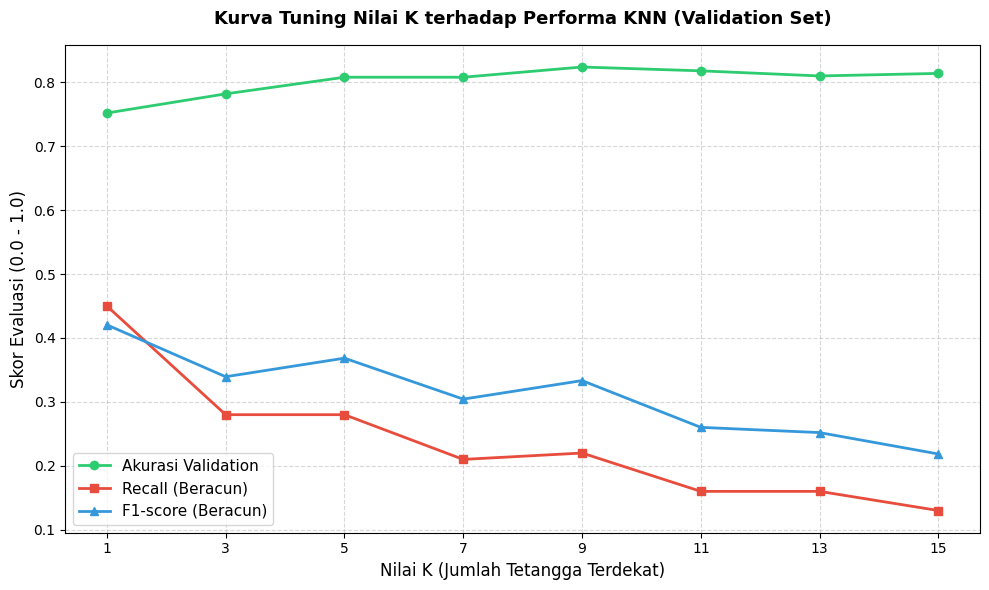


[HASIL] Nilai K terbaik untuk KNN: K = 1 (dengan F1-score Beracun: 0.4206)


In [5]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
val_accuracies = []
val_recalls_toxic = []
val_f1s_toxic = []

print("Mulai proses Hyperparameter Tuning untuk KNN...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_val_pred = knn.predict(X_val_scaled)
    
    acc = accuracy_score(y_val, y_val_pred)
    
    report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)
    recall_tox = report['1']['recall']
    f1_tox = report['1']['f1-score']
    
    val_accuracies.append(acc)
    val_recalls_toxic.append(recall_tox)
    val_f1s_toxic.append(f1_tox)
    print(f"K = {k:2d} | Akurasi: {acc:.4f} | Recall (Beracun): {recall_tox:.4f} | F1-Score (Beracun): {f1_tox:.4f}")

# Visualisasi kurva tuning K
plt.figure(figsize=(10, 6))
plt.plot(k_values, val_accuracies, marker='o', label='Akurasi Validation', color='#2ecc71', linewidth=2)
plt.plot(k_values, val_recalls_toxic, marker='s', label='Recall (Beracun)', color='#e74c3c', linewidth=2)
plt.plot(k_values, val_f1s_toxic, marker='^', label='F1-score (Beracun)', color='#3498db', linewidth=2)
plt.title('Kurva Tuning Nilai K terhadap Performa KNN (Validation Set)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Nilai K (Jumlah Tetangga Terdekat)', fontsize=12)
plt.ylabel('Skor Evaluasi (0.0 - 1.0)', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Memilih K terbaik berdasarkan F1-score tertinggi untuk kelas beracun (prioritas utama)
best_index = np.argmax(val_f1s_toxic)
best_k = k_values[best_index]
print(f"\n[HASIL] Nilai K terbaik untuk KNN: K = {best_k} (dengan F1-score Beracun: {val_f1s_toxic[best_index]:.4f})")

## Sel 10 — Evaluasi Model KNN Terbaik pada Data Test

Menguji model KNN dengan $K$ terbaik pada data Test dan menampilkan visualisasi lengkap berupa:
1. **Classification Report**
2. **Confusion Matrix (Heatmap)**
3. **Kurva ROC dan Nilai AUC**

================ CLASSIFICATION REPORT (DATA TEST) ================
                   precision    recall  f1-score   support

Tidak Beracun (0)       0.83      0.83      0.83       400
      Beracun (1)       0.32      0.31      0.31       100

         accuracy                           0.73       500
        macro avg       0.57      0.57      0.57       500
     weighted avg       0.73      0.73      0.73       500



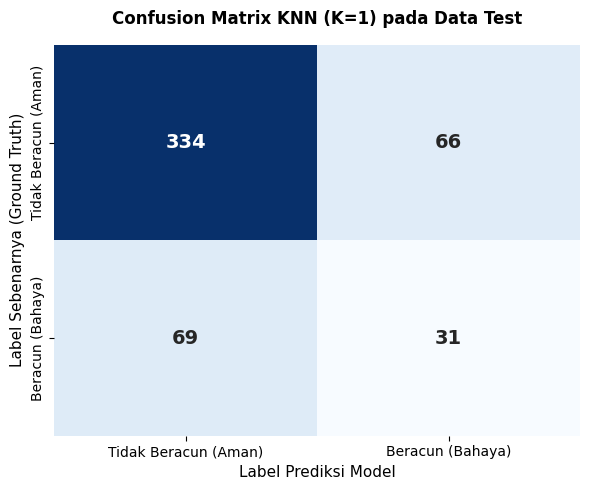

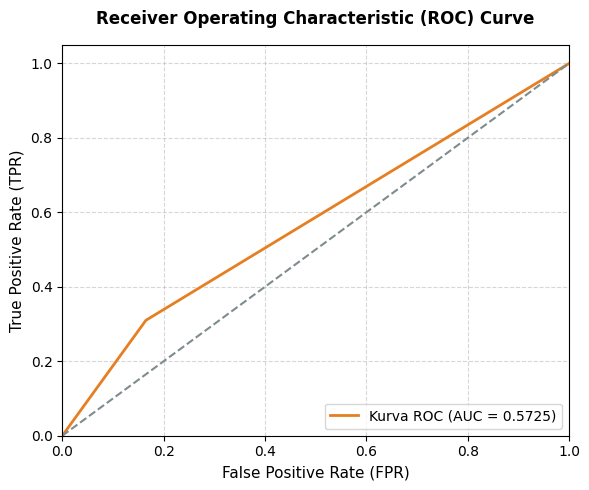

In [6]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# Prediksi pada Test Set
y_test_pred = best_knn.predict(X_test_scaled)
y_test_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

# 1. Cetak classification report
print("================ CLASSIFICATION REPORT (DATA TEST) ================")
print(classification_report(y_test, y_test_pred, target_names=['Tidak Beracun (0)', 'Beracun (1)']))

# 2. Visualisasi Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tidak Beracun (Aman)', 'Beracun (Bahaya)'],
            yticklabels=['Tidak Beracun (Aman)', 'Beracun (Bahaya)'],
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title(f'Confusion Matrix KNN (K={best_k}) pada Data Test', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Label Prediksi Model', fontsize=11)
plt.ylabel('Label Sebenarnya (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()

# 3. Visualisasi Kurva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#e67e22', lw=2, label=f'Kurva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Sel 12 — Visualisasi Contoh Prediksi Citra Kupu-Kupu

Untuk melihat performa klasifikasi secara visual pada data uji lapangan:
- Judul **HIJAU** menunjukkan klasifikasi yang **BENAR**.
- Judul **MERAH** menunjukkan klasifikasi yang **SALAH** (False Negative atau False Positive).

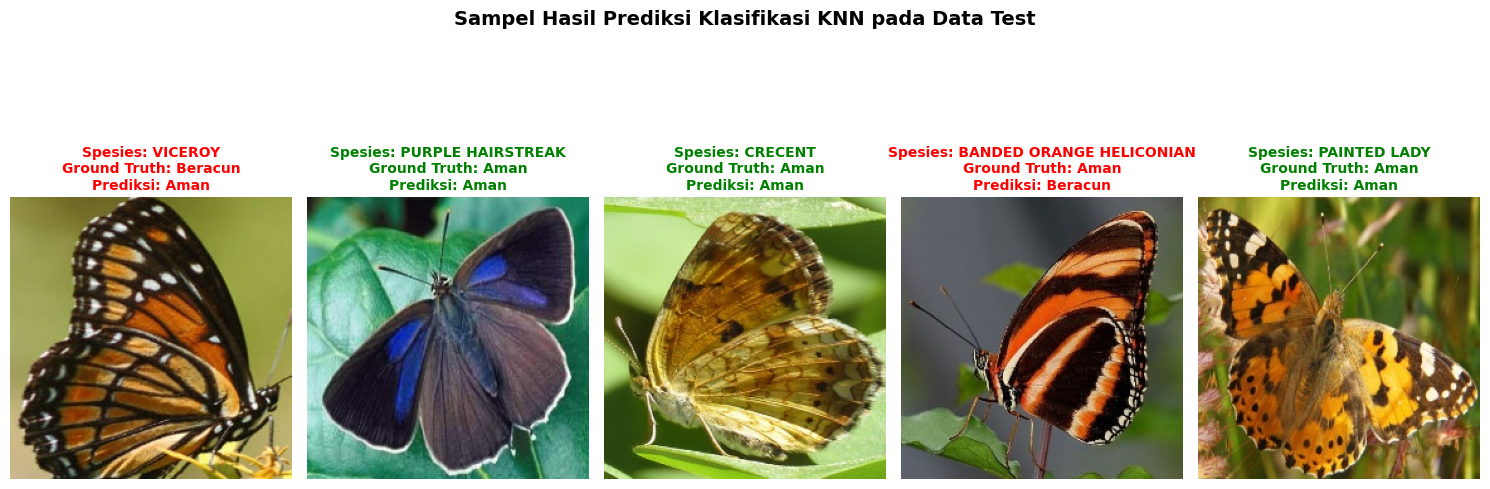

In [7]:
# Ambil 5 gambar acak dari data Test untuk visualisasi
np.random.seed(12) # seed khusus visualisasi agar menghasilkan variasi gambar yang bagus
sample_indices = np.random.choice(len(test_paths), 5, replace=False)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(sample_indices):
    img_path = test_paths[idx]
    true_label = y_test[idx]
    pred_label = y_test_pred[idx]
    species = test_species[idx]
    
    # Load RGB image untuk ditampilkan
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Warna judul gambar berdasarkan kebenaran prediksi
    title_color = 'green' if true_label == pred_label else 'red'
    true_str = 'Beracun' if true_label == 1 else 'Aman'
    pred_str = 'Beracun' if pred_label == 1 else 'Aman'
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img_rgb)
    plt.title(f"Spesies: {species}\nGround Truth: {true_str}\nPrediksi: {pred_str}", 
              color=title_color, fontsize=10, fontweight='bold')
    plt.axis('off')

plt.suptitle("Sampel Hasil Prediksi Klasifikasi KNN pada Data Test", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()